In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import pandas as pd
import pickle
from scipy.stats import zscore

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from dynamax.hidden_markov_model import PoissonHMM


# Get my functions
from segmentation_functions import *

ERROR:2026-08-07 16:21:28,430:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


## Parameters

In [3]:

""" FITTING PARAMETERS """
num_iters = 100
num_states = 2
num_train_batches = 5
method='prior'
fit_method='em'
zsc = False
truncate = False

if truncate:
    fitting_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+str(zsc)+'_truncated/'
else:
    fitting_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+str(zsc)+'/'

# whisker_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+'True/'
# licking_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+'False/'

save_path = prefix + 'representation_learning_variability/paper-individuality/data/hmm/most_likely_states/'+fitting_params
# save_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/hmm/most_likely_states/'+fitting_params
# save_path = prefix + 'representation_learning_variability/paper-individuality/data/training/hmm/most_likely_states/'+fitting_params

# Create folder where to dump data
if not os.path.exists(save_path):
    # Create a new directory because it does not exist
    os.makedirs(save_path)
        
# LOAD DATA
# BWM proficient
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'
wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/paw_wavelets/'

# # NM proficient
# data_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/design_matrices/'
# wavelet_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/paw_wavelets/'

# # BWM first training session
# data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/session_1/'
# # data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/extra_bwm/'
# wavelet_path = prefix + 'representation_learning_variability/paper-individuality/data/training/left_paw_wavelets/'


all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

var_interest = ['Lick count']
# var_interest = ['whisker_me']
# var_interest = ['avg_wheel_vel']


# Individual sessions

In [4]:
# Identify sessions availableto process
grid_search_path = prefix + 'representation_learning_variability/paper-individuality/data/hmm/grid_search/'+fitting_params
# grid_search_path = prefix + 'representation_learning_variability/paper-individuality/segmentation/1_camera_setup/temp_data/hmm/grid_search/'+fitting_params
# grid_search_path = prefix + 'representation_learning_variability/paper-individuality/data/training/hmm/grid_search/'+fitting_params

sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    fit_id = str(mouse_name + session)
    result_filename = os.path.join(grid_search_path, f"best_results_{var_interest[0]}_{fit_id}")
    if os.path.exists(result_filename):
        sessions_to_process.append((mouse_name, session))

print(f"Found {len(sessions_to_process)} sessions to process.")

Found 341 sessions to process.


In [5]:
for m, mat in enumerate(sessions_to_process):
    try:
            
        mouse_name = mat[0]
        session = mat[1]
        
        # mouse_name = 'NR_0020'
        # session = 'd901aff5-2250-467a-b4a1-0cb9729df9e2'
        
        fit_id = str(mouse_name+session)
        filename = wavelet_path + "paw_vel_wavelets_" + str(session) + '_'  + mouse_name
        original_design_matrix = pd.read_parquet(filename)
        # filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
        # original_design_matrix = pd.read_parquet(filename)
        
        # Mask on ONLY the fitted variable(s): a NaN in another column (e.g. right paw,
        # whose wavelet coeffs are all NaN when the paw is untracked) must not drop the
        # bin, since the fit does not depend on it.
        design_matrix = original_design_matrix[var_interest].dropna()
        
        if zsc == True:
            design_matrix[var_interest] = zscore(np.array(design_matrix), axis=0, nan_policy='omit')
        else:
            design_matrix[var_interest] = np.array(design_matrix)
            
        # Prepare data
        num_timesteps = np.shape(design_matrix)[0]
        emission_dim = np.shape(design_matrix)[1]
        shortened_array = np.array(design_matrix[:(num_timesteps // num_train_batches) * num_train_batches])
        train_emissions = jnp.stack(jnp.split(shortened_array, num_train_batches))

        results_file = os.path.join(grid_search_path, 
                                    f"best_results_{var_interest[0]}_{fit_id}")
            
        # Retrieve best fits
        if 'Lick count' in var_interest:
            # Get results from grid search
            all_lls, all_baseline_lls, all_init_params, all_fit_params, _, params = pickle.load(open(results_file, "rb"))
            _, _, kappas = params
            param_num = 1 ## Only search kappas
            bits_LL, all_LL, best_fold = get_bits_LL(all_lls, all_baseline_lls, design_matrix, num_train_batches, params, param_num)
            # bits_LL, all_LL, best_fold = get_bits_LL_kappa(all_lls, all_baseline_lls, design_matrix, num_train_batches, kappas)
            # best_kappa = find_best_param(bits_LL, kappas)
            best_kappa, _, mean_bits_LL = find_best_param(bits_LL, params, param_num)
            index_kappa = np.where(np.array(kappas)==best_kappa)[0][0]
            use_fold = int(best_fold[index_kappa])

            " Fit model with best params"
            best_params = all_fit_params[best_kappa]
            best_parameters = num_states, np.nan, best_kappa
            # Find parameters for best fold
            initial_probs = best_params[0].probs[use_fold]
            transition_matrix = best_params[1].transition_matrix[use_fold]
            emission_rates = best_params[2].rates[use_fold]

            # Initialize new hmm
            test_phmm = PoissonHMM(num_states, emission_dim, transition_matrix_stickiness=best_kappa)
            best_fold_params, props = test_phmm.initialize(key=jr.PRNGKey(0), method=method,
                                            initial_probs=initial_probs,
                                            transition_matrix=transition_matrix,
                                            emission_rates=emission_rates)  # not sure if I need to includea
            # Get state estimates for validation data
            most_likely_states = test_phmm.most_likely_states(best_fold_params, shortened_array)

            # # Plot grid search
            # plt.scatter([kappas]*num_train_batches, bits_LL)
            # plt.errorbar(kappas, np.nanmean(bits_LL, axis=1), np.nanstd(bits_LL, axis=1)/(np.sqrt(5))*1.96)
            # plt.xlabel('Kappa')
            # plt.xticks(np.arange(0, len(kappas), 1), kappas)
            # plt.title(mouse_name + ' ' + var_interest[0])
            # plt.show()
            # print(best_kappa)
        else:
            # Get results from grid search
            all_lls, all_baseline_lls, all_init_params, all_fit_params, _, params = pickle.load(open(results_file, "rb"))
            _, Lags, kappas = params
            param_num = 2 ## Only search kappas
            bits_LL, all_LL, best_fold = get_bits_LL(all_lls, all_baseline_lls, design_matrix, num_train_batches, params, param_num)
            best_kappa, best_lag, mean_bits_LL = find_best_param(bits_LL, params, param_num)

            index_lag = np.where(np.array(Lags)==best_lag)[0][0]
            index_kappa = np.where(np.array(kappas)==best_kappa)[0][0]
            use_fold = int(best_fold[index_kappa, index_lag])
            
            best_parameters = num_states, best_lag, best_kappa
                    
            " Fit model with best params"
            # Compute inputs for required timelags
            my_inputs = compute_inputs(shortened_array, best_lag, emission_dim)
            train_inputs = jnp.stack(jnp.split(my_inputs, num_train_batches))

            best_params = all_fit_params[best_lag][best_kappa]

            # Find parameters for best fold
            initial_probs = best_params[0].probs[use_fold]
            transition_matrix = best_params[1].transition_matrix[use_fold]
            emission_weights = best_params[2].weights[use_fold]
            emission_biases = best_params[2].biases[use_fold]
            emission_covariances = best_params[2].covs[use_fold]

            # Initialize new hmm
            new_arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=best_lag, transition_matrix_stickiness=best_kappa)
            best_fold_params, props = new_arhmm.initialize(key=jr.PRNGKey(0), method=method,
                                            initial_probs=initial_probs,
                                            transition_matrix=transition_matrix,
                                            emission_weights=emission_weights,
                                            emission_biases=emission_biases,
                                            emission_covariances=emission_covariances,
                                            emissions=shortened_array)  # not sure if I need to include

            # Get state estimates for validation data
            most_likely_states = new_arhmm.most_likely_states(best_fold_params, shortened_array, my_inputs)

            # Plot grid search
            plot_grid_search(best_kappa, best_lag, mean_bits_LL.T, kappas, Lags, mouse_name, var_interest[0])        
            plt.scatter([Lags]*num_train_batches, bits_LL[index_kappa, :, :].T)
            plt.plot(Lags, np.nanmean(bits_LL[index_kappa, :, :], axis=1))
            plt.errorbar(Lags, np.nanmean(bits_LL[index_kappa, :, :], axis=1), np.nanstd(bits_LL[index_kappa, :, :], axis=1)/(np.sqrt(5))*1.96)
            plt.ylabel('Delta LL')
            plt.xlabel('Lag')
            plt.show()
            print(best_kappa, best_lag)
            
        to_save = most_likely_states, use_fold, best_parameters

        # Save most_likely_states
        pickle.dump(to_save, open(save_path + var_interest[0] + '_'+ fit_id , "wb"))
    
    except:
        print(mouse_name)


NYU-12
PL024
UCLA049
CSH_ZAD_029
NYU-21
PL015
NYU-21
PL015
UCLA044


## Test licks

Fitting session DY_01136280321-555b-446d-9b7d-c2e17991e090...


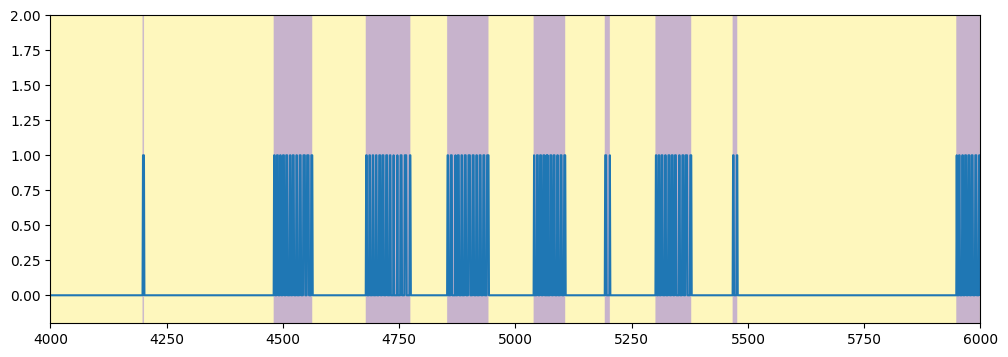

Fitting session DY_009db4df448-e449-4a6f-a0e7-288711e7a75a...


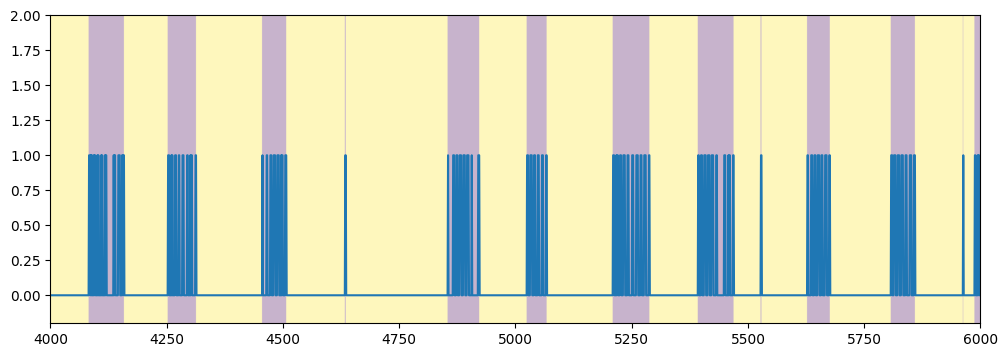

Fitting session ZFM-0237288224abb-5746-431f-9c17-17d7ef806e6a...


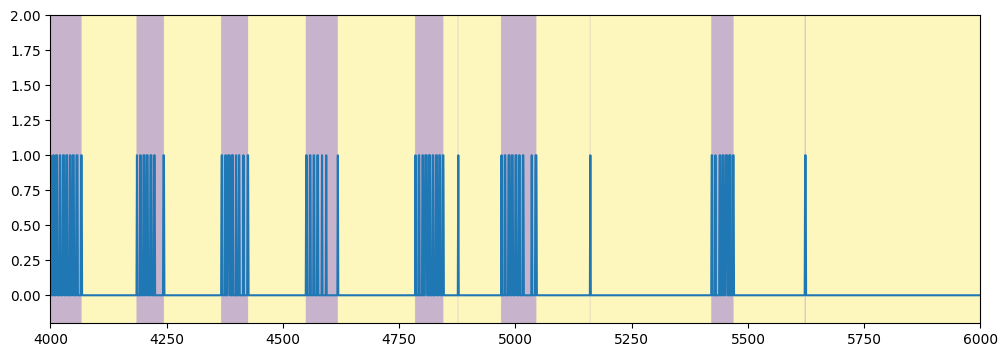

Fitting session NYU-37f88d4dd4-ccd7-400e-9035-fa00be3bcfa8...


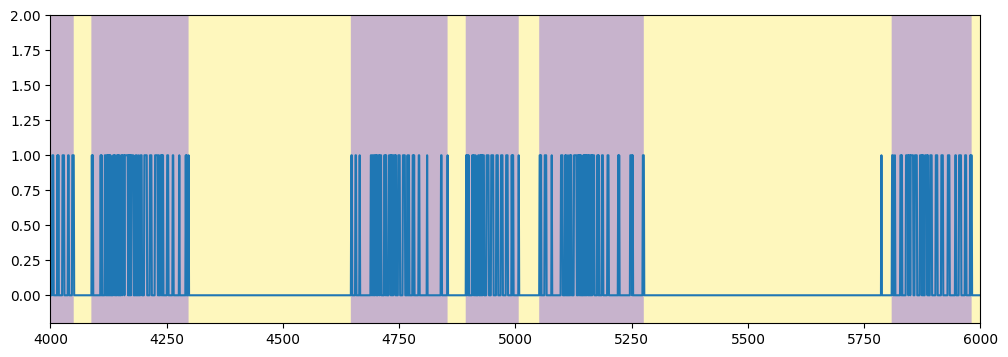

Fitting session DY_010bb6a5aae-2431-401d-8f6a-9fdd6de655a9...


KeyboardInterrupt: 

In [6]:
variables_to_fit = ['Lick count']
kappa = 1

for m, mat in enumerate(idxs):
      mouse_name = mat[37:]
      session = mat[:36]

      # Load mouse/session data
      filename = "design_matrix_" + str(session) + '_'  + mouse_name
      original_design_matrix = pd.read_parquet(data_path + filename)


      # Need to dropnans
      if zsc == True:
              array_matrix = zscore(np.array(original_design_matrix), axis=0, nan_policy='omit')
      else:
              array_matrix = np.array(original_design_matrix)
              
      # filtered_matrix = np.abs(standardized_designmatrix[~np.isnan(standardized_designmatrix).any(axis=1)])
      # Mask on ONLY the fitted variable(s): an unrelated degenerate column
      # (e.g. zero-variance 'Lick count' -> all-NaN after zscore) must not empty
      # the whole session when the fitted variable (e.g. whisker_me) is fine.
      keys = np.where(original_design_matrix.keys().isin(variables_to_fit))[0]
      fit_cols = array_matrix[:, keys]
      not_nan = ~np.isnan(fit_cols).any(axis=1)
      design_matrix = fit_cols[not_nan]   # already (n_timesteps, emission_dim)
      fit_id = str(mouse_name + session)

      # Skip sessions with too little usable data to split into CV batches
      if design_matrix.shape[0] < num_train_batches:
          print(f"Skipping {fit_id}: only {design_matrix.shape[0]} usable rows for {variables_to_fit}")
          continue

      print(f"Fitting session {fit_id}...")

      # Prepare data format
      num_timesteps = np.shape(design_matrix)[0]
      emission_dim = np.shape(design_matrix)[1]
      shortened_array = np.array(design_matrix[:(num_timesteps // num_train_batches) * num_train_batches])
      train_emissions = jnp.stack(jnp.split(shortened_array, num_train_batches))

      test_poishmm = PoissonHMM(num_states, emission_dim, transition_matrix_stickiness=kappa)
      all_val_lls, fit_params, init_params, baseline_lls = cross_validate_poismodel(test_poishmm, jr.PRNGKey(0),
                                                                                        train_emissions, num_train_batches, 'em', num_iters=100)

      use_fold = np.where(all_val_lls==np.nanmax(all_val_lls))[0][0]
      # Find parameters for best fold
      initial_probs = fit_params[0].probs[use_fold]
      transition_matrix = fit_params[1].transition_matrix[use_fold]
      emission_rates = fit_params[2].rates[use_fold]

      # Initialize new hmm
      test_phmm = PoissonHMM(num_states, emission_dim, transition_matrix_stickiness=kappa)
      best_fold_params, props = test_phmm.initialize(key=jr.PRNGKey(0), method=method,
                                        initial_probs=initial_probs,
                                        transition_matrix=transition_matrix,
                                        emission_rates=emission_rates)  # not sure if I need to include

      # Get state estimates for validation data
      most_likely_states = test_phmm.most_likely_states(best_fold_params, shortened_array)
      # Remove states below threshold
      new_states = np.array(most_likely_states).astype(float)
      new_states = most_likely_states

      " Plots "
      fig, ax = plt.subplots(figsize=(12, 4))
      states_to_append =np.arange(0, num_states, 1)
      plot_max = 500
      plot_min = -500

      plt.plot(np.array(design_matrix[:, 0]))
      plt.imshow(np.concatenate([most_likely_states, states_to_append])[None,:],
              extent=(0, len(np.concatenate([most_likely_states, states_to_append])), plot_min, plot_max),
              aspect="auto",
              cmap='viridis',
              alpha=0.3)
      plt.xlim([4000,6000])
      plt.ylim([-.2, 2])
      plt.show()

## Test whisking

Fitting session NR_002027ad66b3-1a52-4304-9e55-afbb801f02d5...


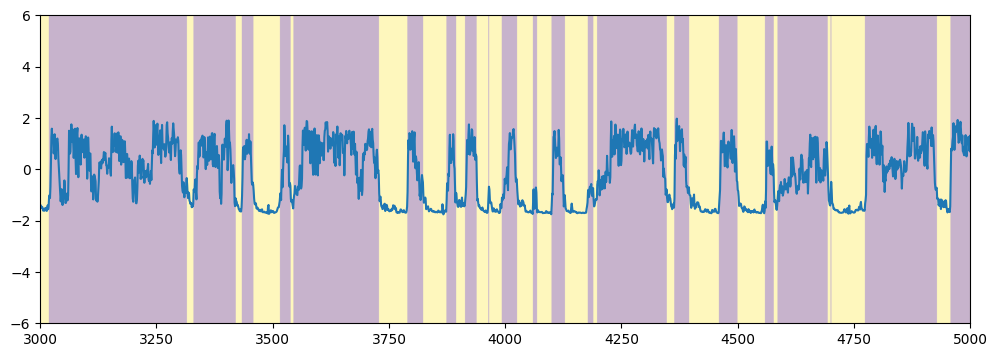

Fitting session NYU-482122f37c-15ab-4963-9c72-bdc514c9edd2...


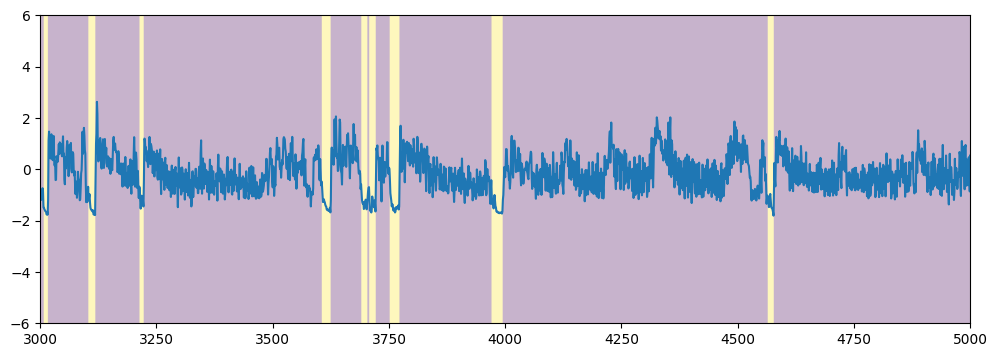

Fitting session PL017f5669b91-3ba8-4304-ba20-4d6bacf83199...


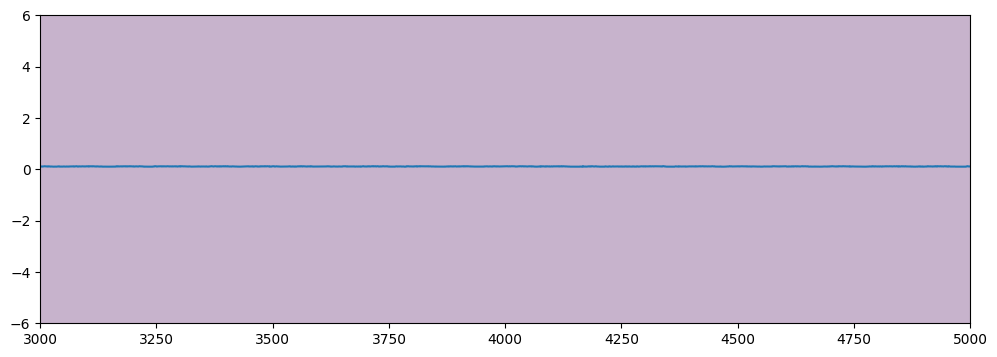

Fitting session ZFM-023695dd0ab4a-b446-4372-9376-94ecbc9ae525...


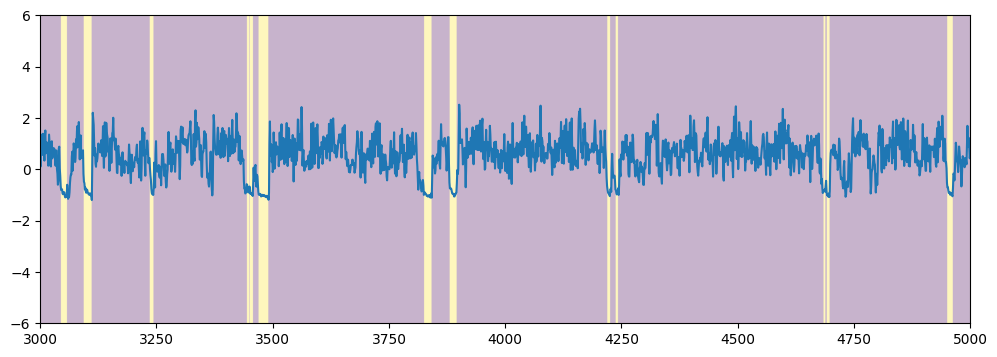

Fitting session ibl_witten_25d9f0c293-df4c-410a-846d-842e47c6b502...


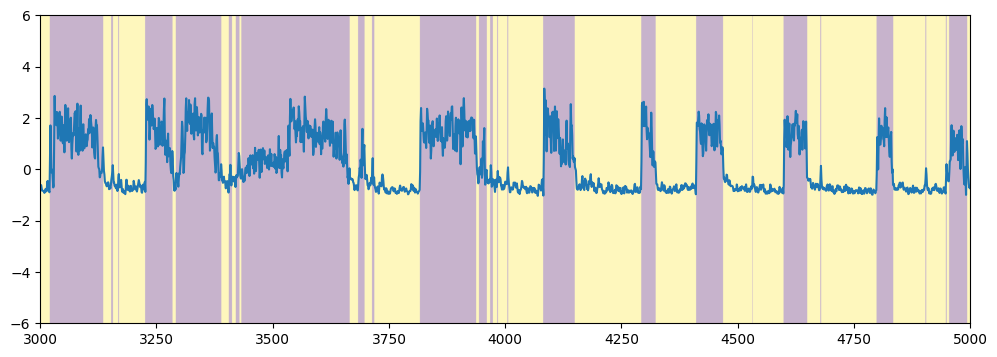

Fitting session UCLA014dcb0bd56-eb5f-44e2-8054-e1892dd84ae7...


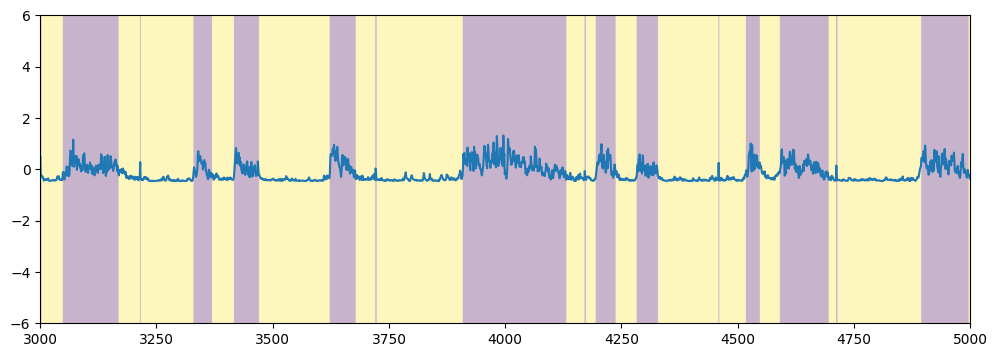

Fitting session PL0318d328397-b5c1-4fed-801b-07d3df49727b...


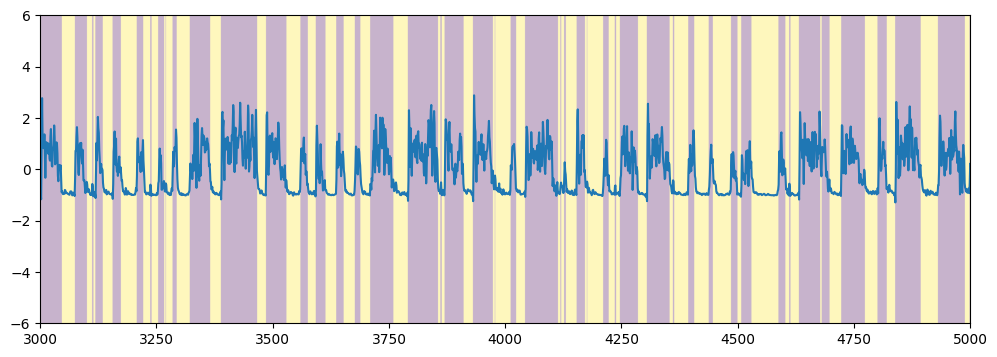

Fitting session NYU-40a28746ff-a6e0-403d-a11d-893c2f9a44b4...


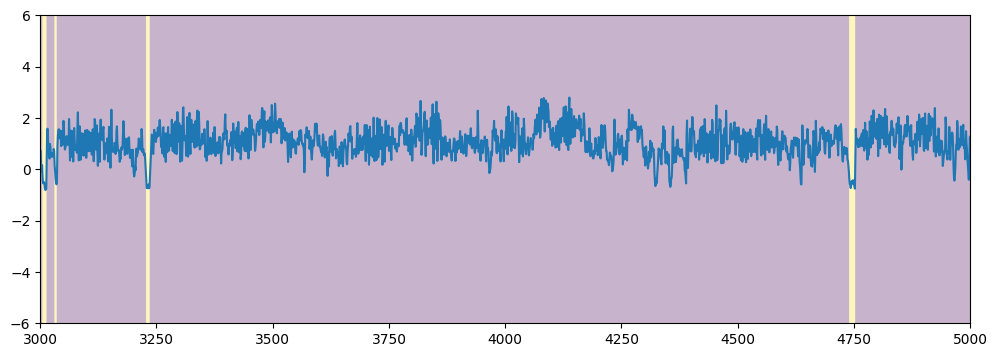

Fitting session UCLA030475280aa-4557-418b-bdcd-f90862de9765...


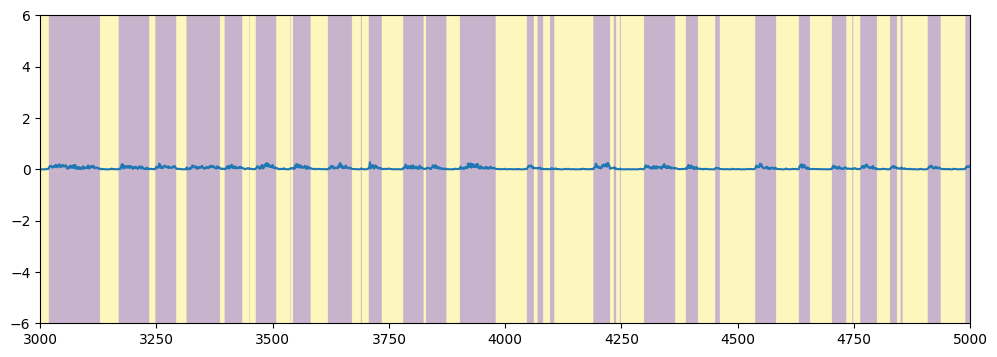

Fitting session UCLA03696bcf9ca-972f-491f-979a-f8b9de2f9477...


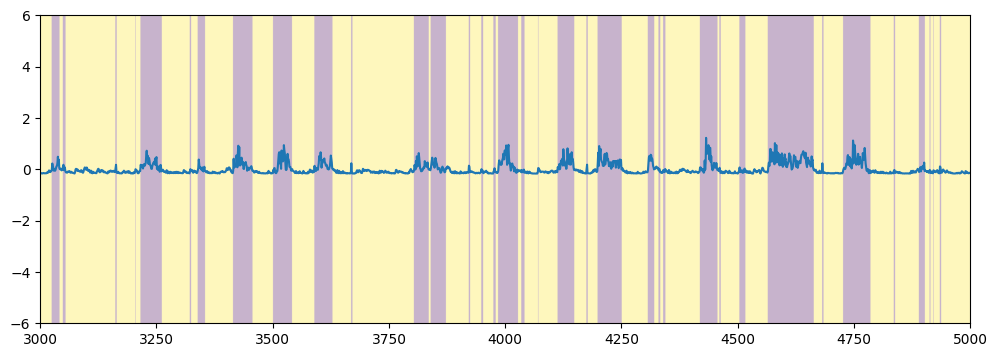

Fitting session DY_020cd76860b-1059-45a2-a0f0-a71f1277fede...


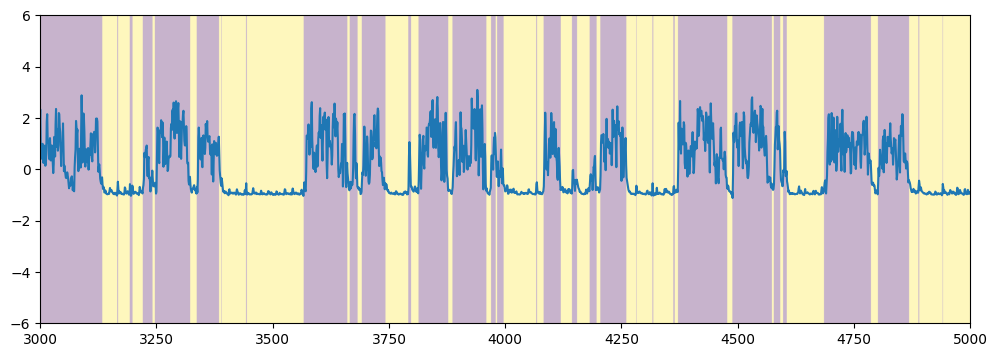

Fitting session UCLA011a353b2d7-cd82-44d8-ac8a-f2ea872e79fe...


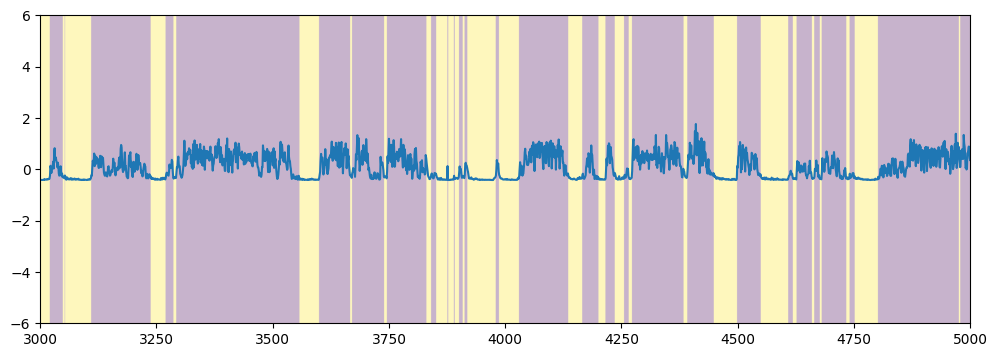

Fitting session ibl_witten_29bf829cc3-8b99-4b6f-8f83-b2506e66e3d2...


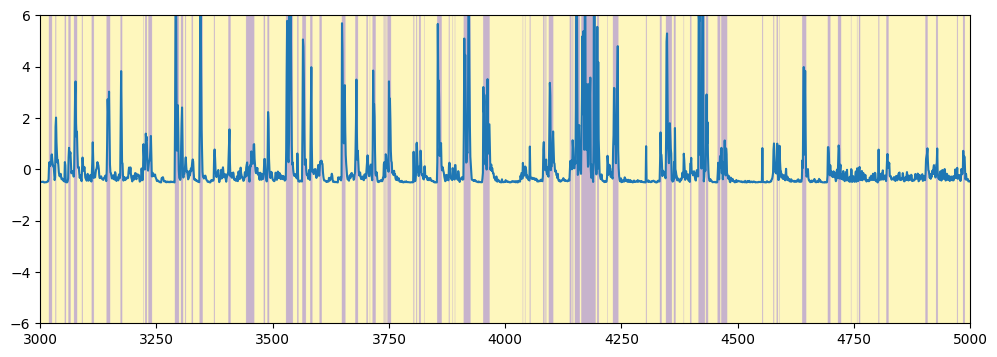

Fitting session SWC_039e34ee0ad-3ad8-4faa-b4d5-c1cc0cf3b496...


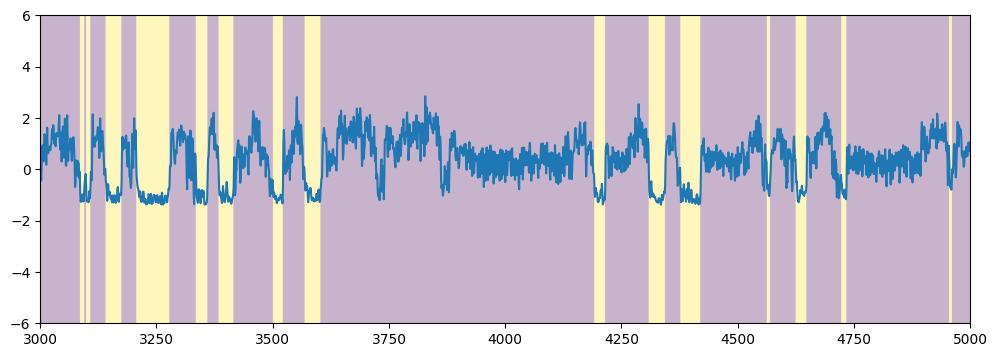

Fitting session UCLA0481fc4387b-0da4-49e9-891c-559ad1de3ce4...


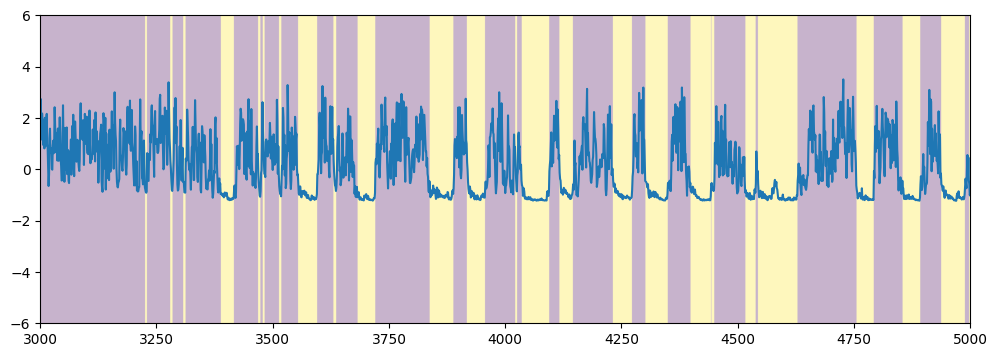

Fitting session PL03435fa2d88-2f6b-4b45-9162-b5b3f99feeab...


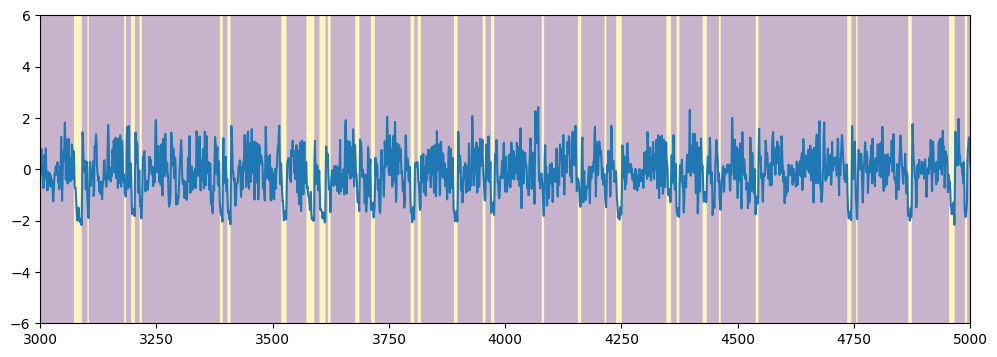

Fitting session UCLA0491aa9254a-38ff-427a-87d8-c5db81127a77...


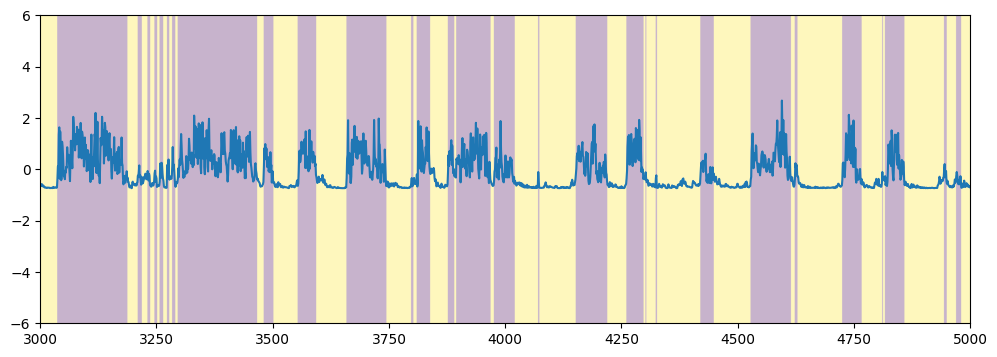

Fitting session NYU-307691eeb3-715b-4571-8fda-6bb57aab8253...


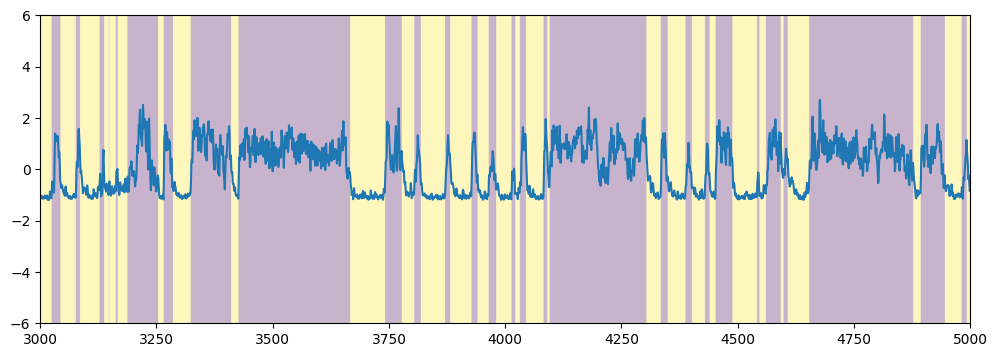

Fitting session PL015bd8b204f-a42e-45c1-a8f0-71c6223a6657...


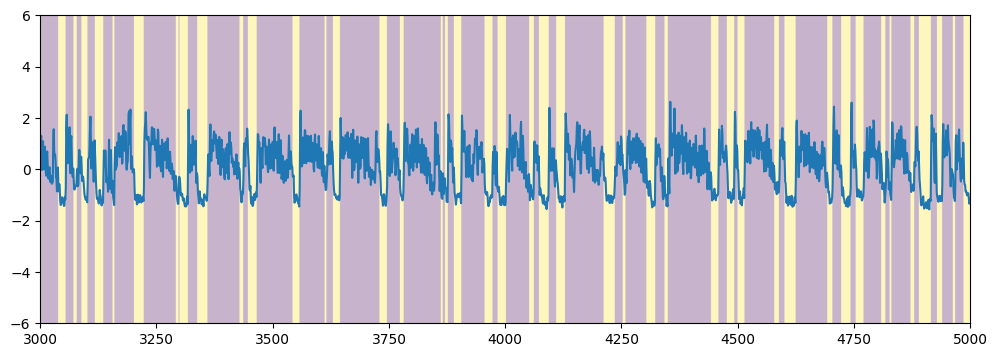

Fitting session ZFM-023731fa00887-138e-4ba7-becb-cca24dac7eb6...


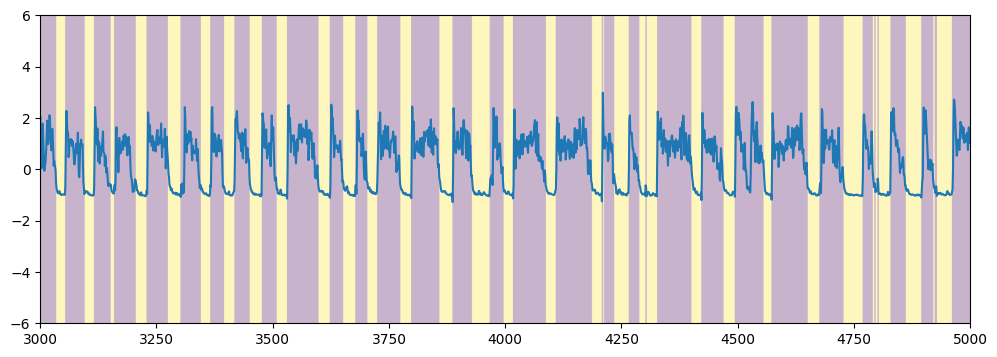

Fitting session UCLA0341a61dd23-1fde-4efb-973c-d473797691d8...


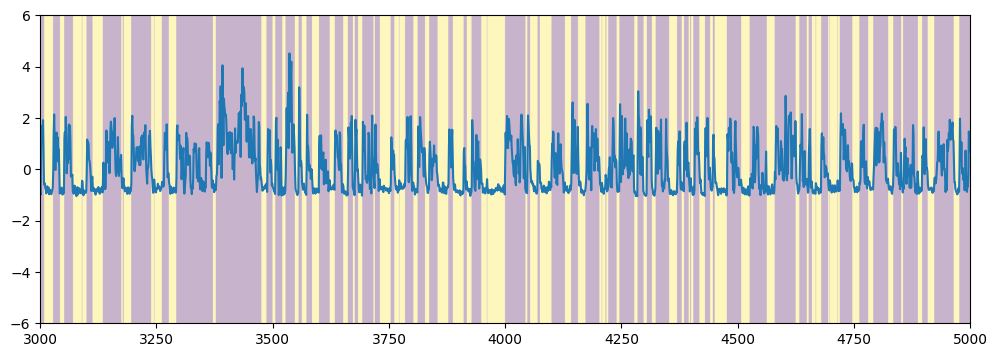

Fitting session NYU-39d190ff16-992c-45e3-8998-de71a89fe7ed...


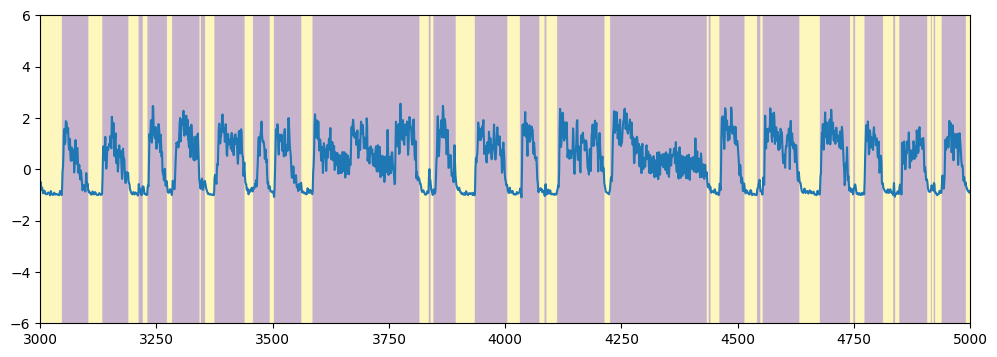

Fitting session ZFM-01937815513ae-d0a0-4744-b829-8d5348abe081...


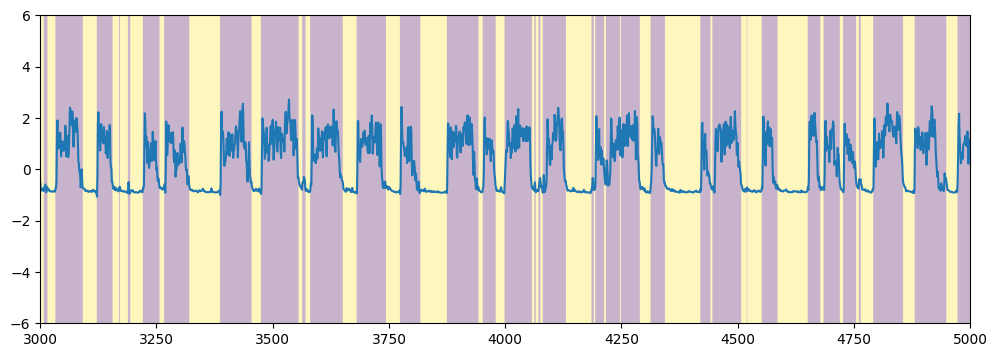

Fitting session NR_0017f3eeb2d4-87ce-49ae-8a74-21665f6f1536...


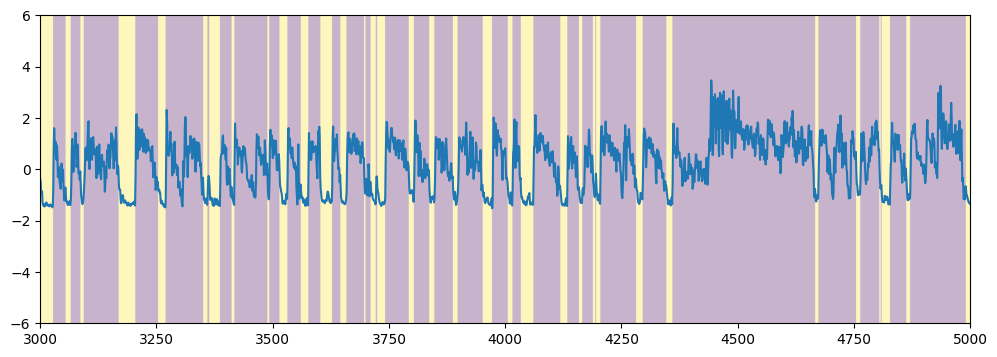

Fitting session NYU-46974832b9-89e5-4897-bfdc-ba9b48b7a4c2...


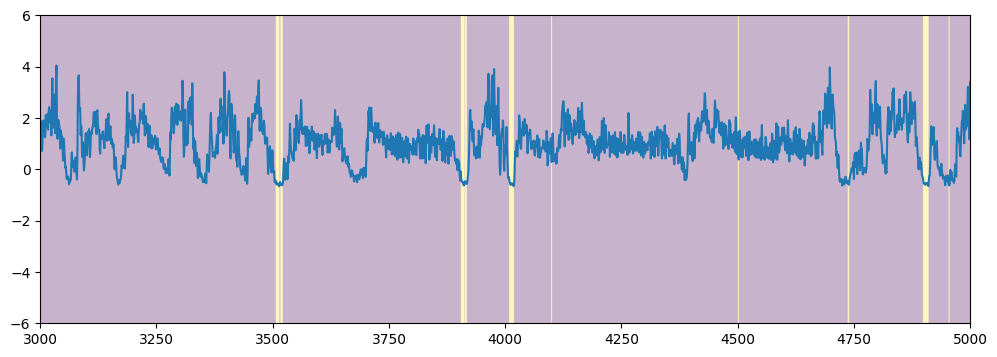

Fitting session ZFM-023689e5f18ea-de7e-4efd-8d6f-f4a143be074b...


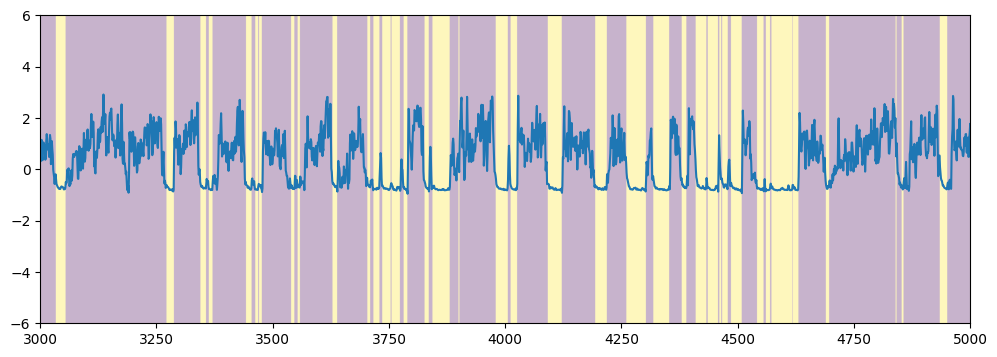

Fitting session DY_018b8250a17-8a0e-4fb4-a7c6-44c1d7ebb322...


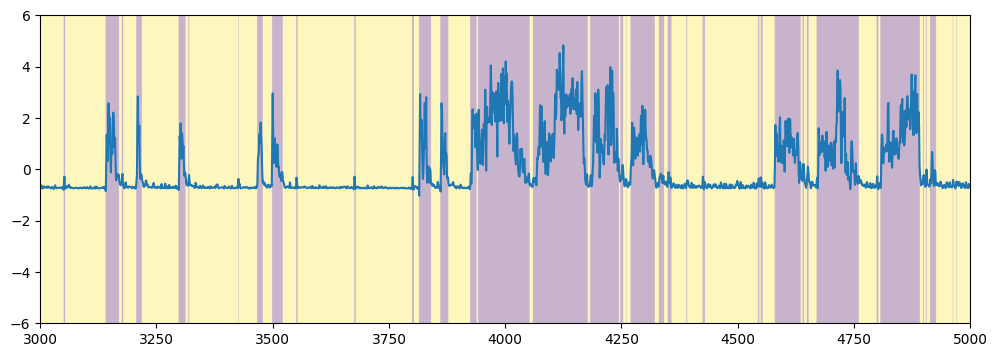

Fitting session UCLA012999ad2ec-0253-40cb-8b5e-8b56b1e1154a...


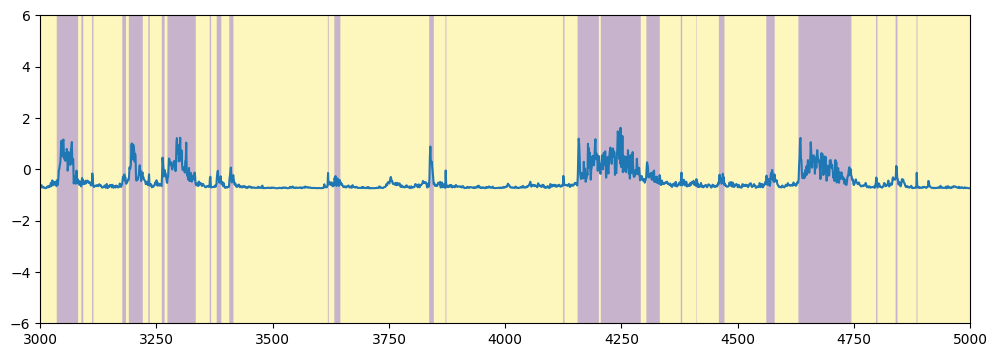

Fitting session NYU-47f140a2ec-fd49-4814-994a-fe3476f14e66...


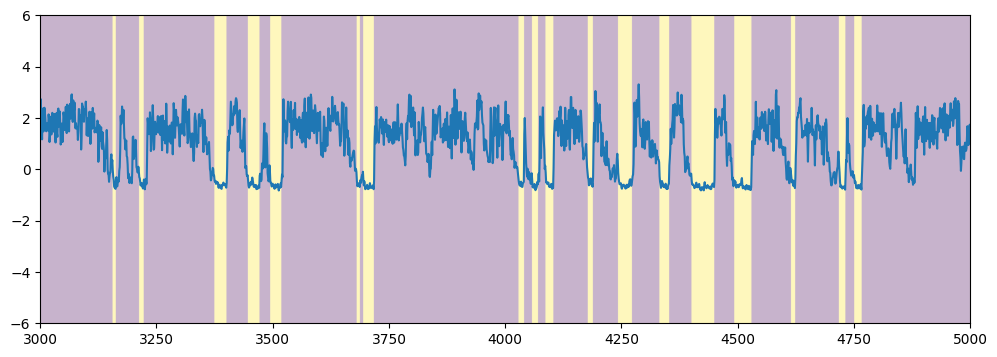

Fitting session UCLA005e8d4d715-8265-458d-85cd-d096bb4b4c52...


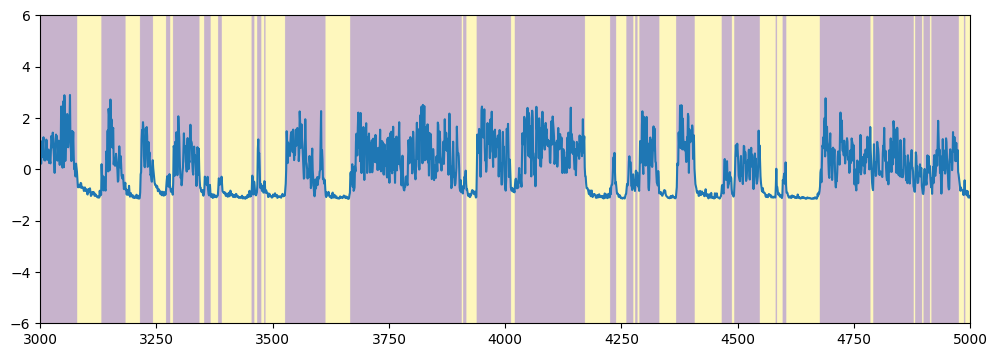

Fitting session UCLA037bfec1493-4e2c-43b2-80de-e12015495a92...


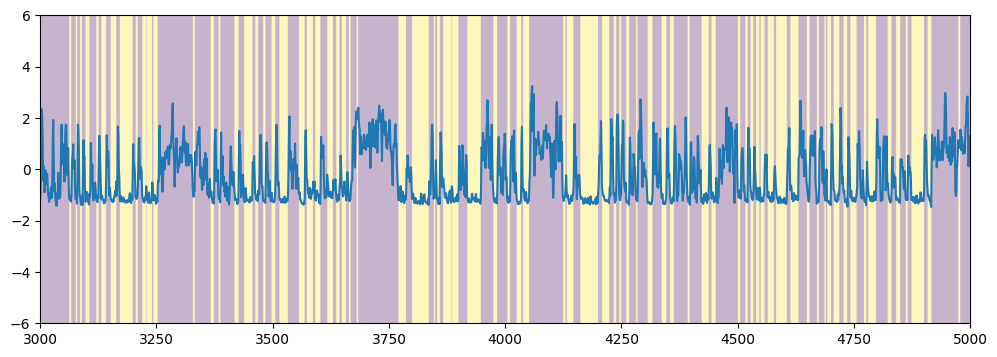

Fitting session SWC_065ee249289-4a21-4b60-b9d8-c32d4faee66b...


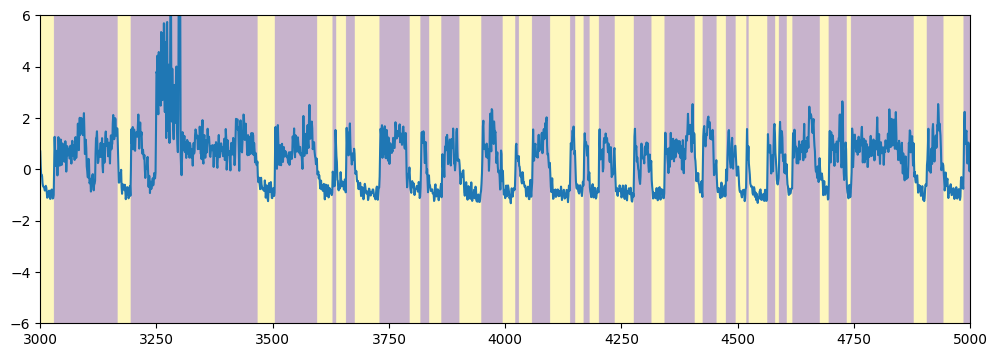

Fitting session UCLA0525e3f2342-4952-4894-864f-d7a181072ab5...


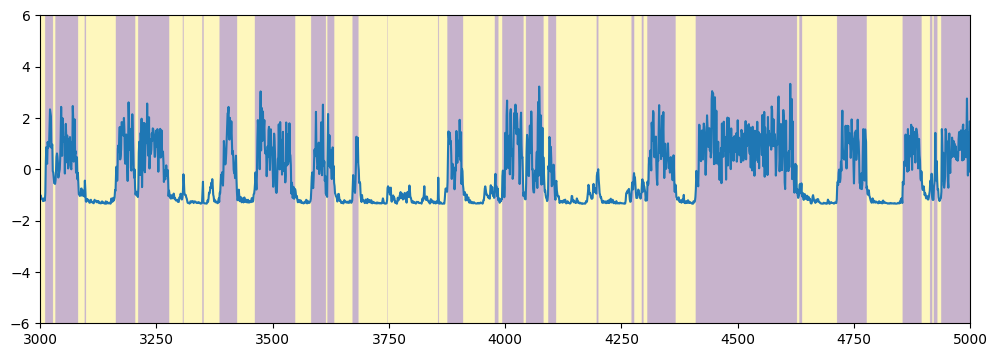

Fitting session SWC_06613b70283-e8d3-4e69-ae3f-83f50c9602e2...


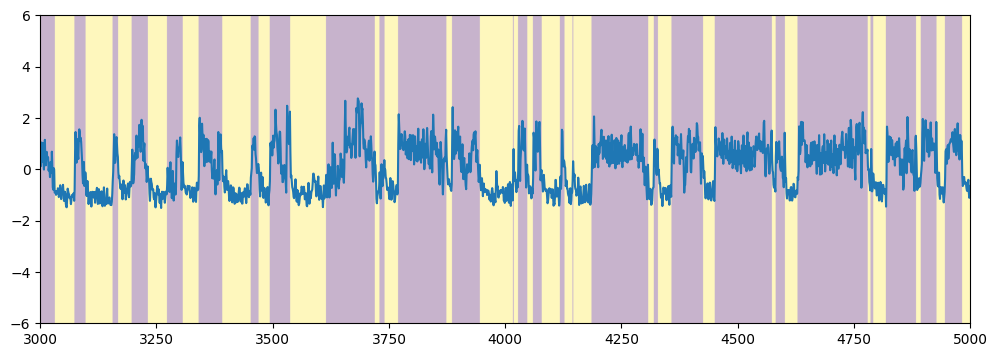

Fitting session ZFM-019361e56bf02-d888-4259-9484-f6b9e3451997...


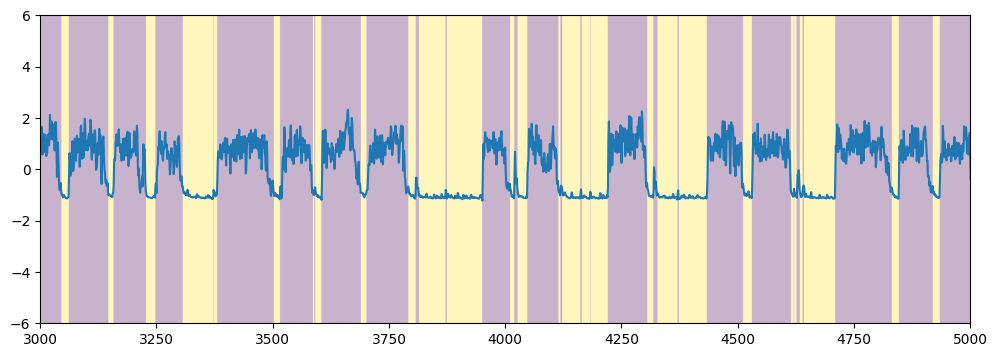

Fitting session NR_0021ba5952cb-9219-458f-a153-2a33637beb70...


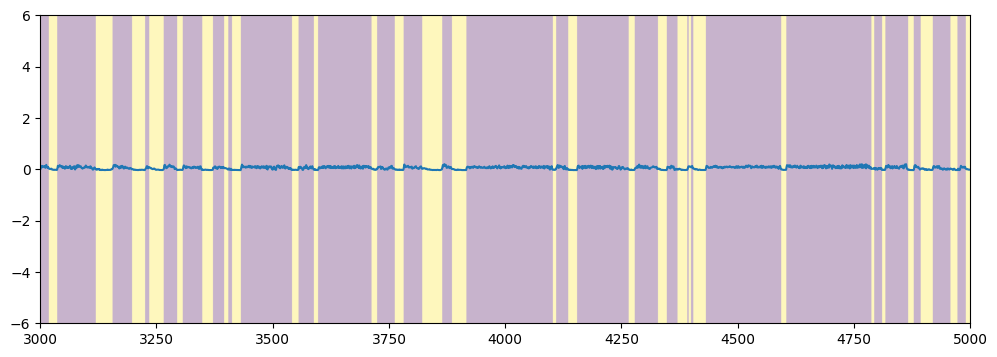

Fitting session ZFM-01935c8337aff-5b94-408d-89b9-b2d9110ac33d...


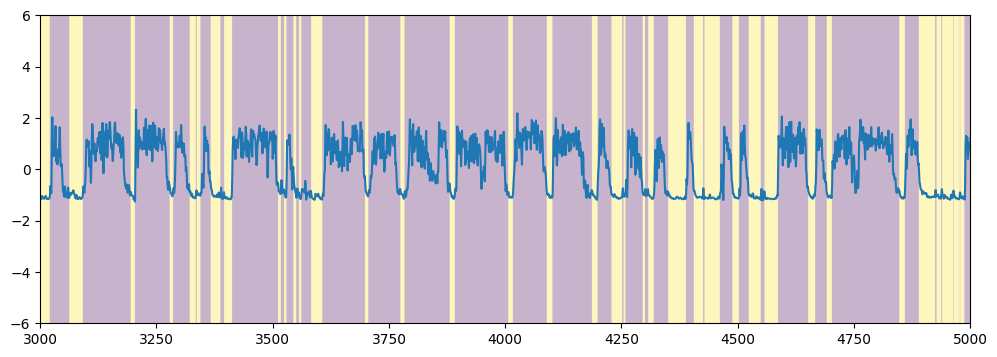

Fitting session ibl_witten_2686f741b4-9dee-4c28-8ee9-49f3656ab419...


In [ ]:
variables_to_fit = ['whisker_me']
# variables_to_fit = ['avg_wheel_vel']
num_lags = 1
kappa=0
for m, mat in enumerate(idxs):
      mouse_name = mat[37:]
      session = mat[:36]
      
#       mouse_name = 'NRkc5-2250-467a-b4a1-0cb9729df9e2'
    
      # Load mouse/session data
      filename = "design_matrix_" + str(session) + '_'  + mouse_name
      original_design_matrix = pd.read_parquet(data_path + filename)

      # Need to dropnans
      if zsc == True:
              array_matrix = zscore(np.array(original_design_matrix), axis=0, nan_policy='omit')
      else:
              array_matrix = np.array(original_design_matrix)
              
      # filtered_matrix = np.abs(standardized_designmatrix[~np.isnan(standardized_designmatrix).any(axis=1)])
      # Mask on ONLY the fitted variable(s): an unrelated degenerate column
      # (e.g. zero-variance 'Lick count' -> all-NaN after zscore) must not empty
      # the whole session when the fitted variable (e.g. whisker_me) is fine.
      keys = np.where(original_design_matrix.keys().isin(variables_to_fit))[0]
      fit_cols = array_matrix[:, keys]
      not_nan = ~np.isnan(fit_cols).any(axis=1)
      design_matrix = fit_cols[not_nan]   # already (n_timesteps, emission_dim)
      fit_id = str(mouse_name + session)

      # Skip sessions with too little usable data to split into CV batches
      if design_matrix.shape[0] < num_train_batches:
          print(f"Skipping {fit_id}: only {design_matrix.shape[0]} usable rows for {variables_to_fit}")
          continue

      print(f"Fitting session {fit_id}...")

      # Prepare data format
      num_timesteps = np.shape(design_matrix)[0]
      emission_dim = np.shape(design_matrix)[1]
      shortened_array = np.array(design_matrix[:(num_timesteps // num_train_batches) * num_train_batches])
      train_emissions = jnp.stack(jnp.split(shortened_array, num_train_batches))

      test_arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags, transition_matrix_stickiness=kappa)
      # Compute inputs for required timelags
      my_inputs = compute_inputs(shortened_array, num_lags, emission_dim)
      train_inputs = jnp.stack(jnp.split(my_inputs, num_train_batches))

      all_val_lls, fit_params, init_params, baseline_lls = cross_validate_armodel(test_arhmm, jr.PRNGKey(0),
                                          train_emissions, train_inputs, method, num_train_batches, 'em')

      use_fold = np.where(all_val_lls==np.nanmax(all_val_lls))[0][0]
      # Find parameters for best fold
      initial_probs = fit_params[0].probs[use_fold]
      transition_matrix = fit_params[1].transition_matrix[use_fold]
      emission_weights = fit_params[2].weights[use_fold]
      emission_biases = fit_params[2].biases[use_fold]
      emission_covariances = fit_params[2].covs[use_fold]

      # Initialize new hmm
      new_arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags, transition_matrix_stickiness=kappa)
      best_fold_params, props = new_arhmm.initialize(key=jr.PRNGKey(0), method=method,
                                      initial_probs=initial_probs,
                                      transition_matrix=transition_matrix,
                                      emission_weights=emission_weights,
                                      emission_biases=emission_biases,
                                      emission_covariances=emission_covariances,
                                      emissions=shortened_array)  # not sure if I need to include

      # Get state estimates for validation data
      most_likely_states = new_arhmm.most_likely_states(best_fold_params, shortened_array, my_inputs)

      # Remove states below threshold
      new_states = np.array(most_likely_states).astype(float)
      new_states = most_likely_states

      " Plots "
      fig, ax = plt.subplots(figsize=(12, 4))
      states_to_append =np.arange(0, num_states, 1)
      plot_max = 500
      plot_min = -500

      plt.plot(np.array(design_matrix[:, 0]))
#       plt.plot(np.array(design_matrix[:, 1]))
      # plt.plot(np.array(design_matrix[:, 2]))
      # plt.plot(np.array(design_matrix[:, 3]))

      plt.imshow(np.concatenate([most_likely_states, states_to_append])[None,:],
              extent=(0, len(np.concatenate([most_likely_states, states_to_append])), plot_min, plot_max),
              aspect="auto",
              cmap='viridis',
              alpha=0.3)
      plt.xlim([3000,5000])
      plt.ylim([-6, 6])
      plt.show()